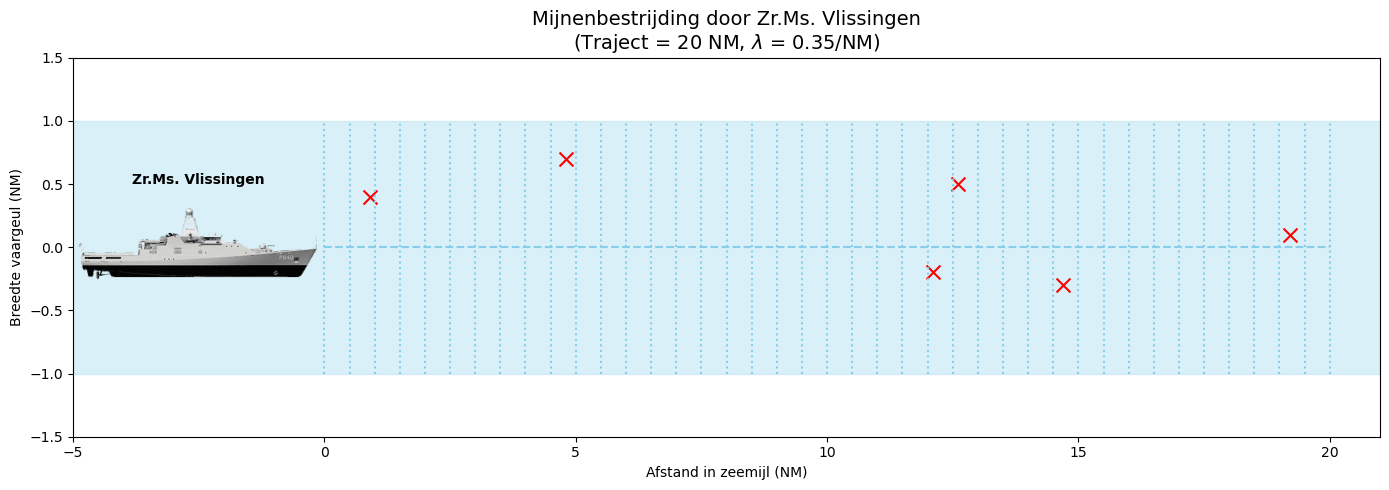

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 1. Parameters voor de simulatie
L = 20      # Lengte van het traject in zeemijl (NM)
W = 2       # Breedte van de vaargeul (TSS) in NM
lam = 0.35   # Gemiddelde dichtheid (lambda) per NM

mu = lam * L
n_mines = np.random.poisson(mu)
# x_mines = np.random.uniform(0, L, n_mines)
# y_mines = np.random.uniform(-W/2, W/2, n_mines)

x_mines = [0.9, 4.8, 12.1, 12.6, 14.7, 19.2]
y_mines = [0.4,  0.7, -0.2, 0.5, -0.3, 0.1]

# 2. Visualisatie opzetten
fig, ax = plt.subplots(figsize=(14, 5))

# Teken de vaargeul (blauw water)
ax.axhspan(-W/2, W/2, color='skyblue', alpha=0.3, label='Vaargeul')
ax.plot([0, L], [0,0], linestyle="dashed", color="skyblue")

# 3. Voeg de Zr.Ms. Vlissingen toe als afbeelding
try:
    img = plt.imread('./Figures/minesweeper-removebg-preview.png') # Zorg dat de bestandsnaam klopt
    
    # zoom bepaalt de grootte van het schip in de plot
    imagebox = OffsetImage(img, zoom=0.5, resample=True)
    imagebox.image.axes = ax

    # We plaatsen het schip aan het begin van het traject (x=1, y=1)
    ab = AnnotationBbox(imagebox, (-2.5, 0), frameon=False, pad=0)

    ax.add_artist(ab)
    ax.text(-2.5, 0.5, 'Zr.Ms. Vlissingen', ha='center', fontweight='bold')
except:
    ax.text(0, 0.5, '(Schip niet gevonden)', fontsize=12)

# segments = np.linspace(0, 20, 40)
# for i in segments:
#     ax.plot([i,i], [-W/2, W/2], linestyle="dotted", color="skyblue")

# 4. Teken de mijnen (red x)
ax.scatter(x_mines, y_mines, color='red', marker='x', s=100, label=f'Zeemijnen')

# Opmaak
ax.set_title(f'Mijnenbestrijding door Zr.Ms. Vlissingen\n(Traject = {L} NM, $\\lambda$ = {lam}/NM)', fontsize=14)
ax.set_xlabel('Afstand in zeemijl (NM)')
ax.set_ylabel('Breedte vaargeul (NM)')
ax.set_xlim(-5, L+1)
ax.set_ylim(-W/2-0.5, W/2 + 0.5)
# ax.grid(True, linestyle='--', alpha=0.5)
# ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("./Figures/example_naval_minesweeper.png")

n_segments = 40
segments = np.linspace(0, 20, n_segments + 1)
for i in segments:
    ax.plot([i,i], [-W/2, W/2], linestyle="dotted", color="skyblue")
plt.savefig("./Figures/example_naval_minesweeper_segmented.png")

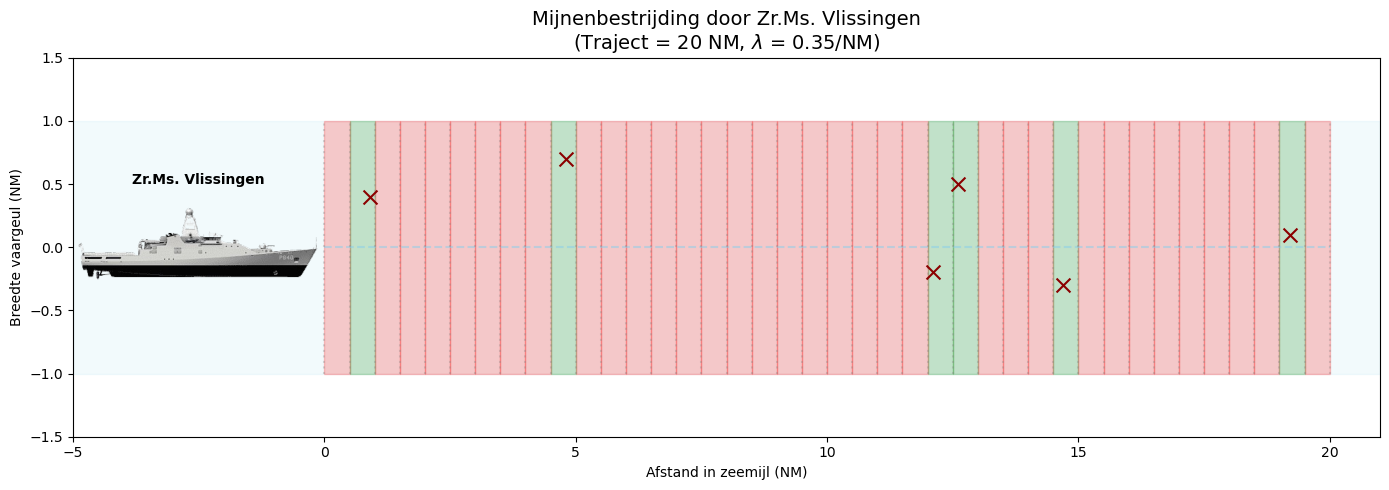

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 1. Parameters voor de simulatie
L = 20      # Lengte van het traject in zeemijl (NM)
W = 2       # Breedte van de vaargeul (TSS) in NM
lam = 0.35  # Gemiddelde dichtheid (lambda) per NM

# Handmatige locaties van de mijnen
x_mines = [0.9, 4.8, 12.1, 12.6, 14.7, 19.2]
y_mines = [0.4, 0.7, -0.2, 0.5, -0.3, 0.1]
n_mines = len(x_mines)

# 2. Visualisatie opzetten
fig, ax = plt.subplots(figsize=(14, 5))

# Teken de vaargeul basis (blauw water)
ax.axhspan(-W/2, W/2, color='skyblue', alpha=0.1, label='Vaargeul')
ax.plot([0, L], [0, 0], linestyle="dashed", color="skyblue", alpha=0.5)

# 3. Segmentatie en Shading
# We maken 40 segmenten van 0 tot 20 (elk segment is 0.5 NM)
n_segments = 40
segments = np.linspace(0, L, n_segments + 1)

for i in range(len(segments) - 1):
    left = segments[i]
    right = segments[i+1]
    
    # Check of er een mijn in dit segment valt
    mine_in_segment = any(left <= mx < right for mx in x_mines)
    
    # Kleur bepalen: Groen als er een mijn is, anders Rood
    color = 'green' if mine_in_segment else 'red'
    
    # Teken de shading voor dit segment
    ax.axvspan(left, right, ymin=1/6, ymax=5/6, color=color, alpha=0.2)
    
    # Teken de verticale stippellijn
    ax.plot([left, left], [-W/2, W/2], linestyle="dotted", color="gray", alpha=0.3)

# Laatste verticale lijn
ax.plot([L, L], [-W/2, W/2], linestyle="dotted", color="gray", alpha=0.3)

# 4. Voeg de Zr.Ms. Vlissingen toe
try:
    img = plt.imread('./Figures/minesweeper-removebg-preview.png') 
    imagebox = OffsetImage(img, zoom=0.5, resample=True)
    ab = AnnotationBbox(imagebox, (-2.5, 0), frameon=False, pad=0)
    ax.add_artist(ab)
    ax.text(-2.5, 0.5, 'Zr.Ms. Vlissingen', ha='center', fontweight='bold')
except:
    ax.text(-2.5, 0, '🚢', fontsize=20, ha='center')

# 5. Teken de mijnen (red x)
ax.scatter(x_mines, y_mines, color='darkred', marker='x', s=100, label='Gedetecteerde zeemijnen', zorder=5)

# Opmaak
ax.set_title(f'Mijnenbestrijding door Zr.Ms. Vlissingen\n(Traject = {L} NM, $\\lambda$ = {lam}/NM)', fontsize=14)
ax.set_xlabel('Afstand in zeemijl (NM)')
ax.set_ylabel('Breedte vaargeul (NM)')
ax.set_xlim(-5, L + 1)
ax.set_ylim(-W/2-0.5, W/2 + 0.5)

# Custom legend voor de kleuren
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='x', color='darkred', label='Zeemijn', linestyle='None'),
    # Line2D([0], [0], color='green', alpha=0.3, lw=4, label='Segment met mijn (Succes)'),
    # Line2D([0], [0], color='red', alpha=0.3, lw=4, label='Segment zonder mijn (Mislukking)')
]
# ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig("./Figures/example_naval_minesweeper_binomial.png")

# Exponentiele verdeling

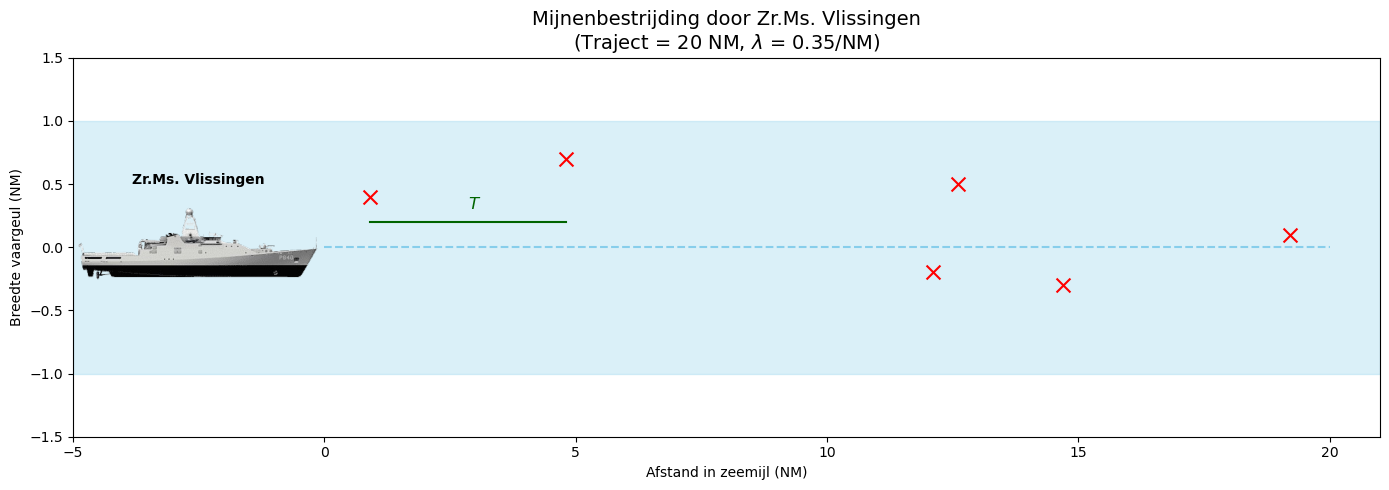

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 1. Parameters voor de simulatie
L = 20      # Lengte van het traject in zeemijl (NM)
W = 2       # Breedte van de vaargeul (TSS) in NM
lam = 0.35   # Gemiddelde dichtheid (lambda) per NM

mu = lam * L
n_mines = np.random.poisson(mu)
# x_mines = np.random.uniform(0, L, n_mines)
# y_mines = np.random.uniform(-W/2, W/2, n_mines)

x_mines = [0.9, 4.8, 12.1, 12.6, 14.7, 19.2]
y_mines = [0.4,  0.7, -0.2, 0.5, -0.3, 0.1]

# 2. Visualisatie opzetten
fig, ax = plt.subplots(figsize=(14, 5))

# Teken de vaargeul (blauw water)
ax.axhspan(-W/2, W/2, color='skyblue', alpha=0.3, label='Vaargeul')
ax.plot([0, L], [0,0], linestyle="dashed", color="skyblue")

# 3. Voeg de Zr.Ms. Vlissingen toe als afbeelding
try:
    img = plt.imread('./Figures/minesweeper-removebg-preview.png') # Zorg dat de bestandsnaam klopt
    
    # zoom bepaalt de grootte van het schip in de plot
    imagebox = OffsetImage(img, zoom=0.5, resample=True)
    imagebox.image.axes = ax

    # We plaatsen het schip aan het begin van het traject (x=1, y=1)
    ab = AnnotationBbox(imagebox, (-2.5, 0), frameon=False, pad=0)

    ax.add_artist(ab)
    ax.text(-2.5, 0.5, 'Zr.Ms. Vlissingen', ha='center', fontweight='bold')
except:
    ax.text(0, 0.5, '(Schip niet gevonden)', fontsize=12)

# 4. Teken de mijnen (red x)
ax.scatter(x_mines, y_mines, color='red', marker='x', s=100, label=f'Zeemijnen')

# 5. Teken de afstand tussen eerste en tweede mijn
ax.plot([x_mines[0], x_mines[1]], [y_mines[0]-0.2, y_mines[0]-0.2], color="darkgreen")
ax.text((x_mines[0]+x_mines[1])/2, y_mines[0]-0.1, r"$T$", fontsize=12, color="darkgreen")

# Opmaak
ax.set_title(f'Mijnenbestrijding door Zr.Ms. Vlissingen\n(Traject = {L} NM, $\\lambda$ = {lam}/NM)', fontsize=14)
ax.set_xlabel('Afstand in zeemijl (NM)')
ax.set_ylabel('Breedte vaargeul (NM)')
ax.set_xlim(-5, L+1)
ax.set_ylim(-W/2-0.5, W/2 + 0.5)
# ax.grid(True, linestyle='--', alpha=0.5)
# ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("./Figures/example_naval_minesweeper_exponential.png")